# Project - Electricity Demand Forecasting with Google TimesFM

This notebook uses **TimesFM 2.0 (500M)** by Google Research to forecast electricity demand. Same dataset and train/test split as the XGBoost baseline, with a direct comparison at the end.

## 1. Import Dependencies

In [1]:
!pip install timesfm



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import torch
from timesfm import TimesFmHparams, TimesFmCheckpoint, TimesFm
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Torch version:", torch.__version__)

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)].
Torch version: 2.12.0+cpu


## 2. Load Data from DuckDB

In [3]:
DB_PATH = r"C:\Users\tusha\Desktop\ML\project_elec_demand\electricity_data.db"
con = duckdb.connect(DB_PATH)
data = con.execute("""
    SELECT
        timestamp AS Timestamp,
        hour, dayofweek, month, year, dayofyear,
        temperature AS Temperature,
        humidity AS Humidity,
        demand AS Demand
    FROM demand_records
    ORDER BY timestamp
""").fetchdf()
con.close()
print(f"Loaded {len(data)} rows")
data.head()

Loaded 43837 rows


,Timestamp,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand
0,2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873
1,2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785
2,2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381
3,2020-01-01 03:00:00,3,2,1,2020,1,3.000000,72.629379,2174.232422
4,2020-01-01 04:00:00,4,2,1,2020,1,3.881208,90.582443,2472.453125


## 3. Feature Engineering (same as XGBoost pipeline)

In [4]:
data["Timestamp"] = pd.to_datetime(data["Timestamp"])
data = data.set_index("Timestamp")
data["quarter"] = data.index.quarter
data["weekofyear"] = data.index.isocalendar().week.astype(int)
data["is_weekend"] = data.index.dayofweek.isin([5, 6]).astype(int)
print(f"Shape after feature engineering: {data.shape}")
data.head(3)

Shape after feature engineering: (43837, 11)


,hour,dayofweek,month,year,dayofyear,Temperature,Humidity,Demand,quarter,weekofyear,is_weekend
Timestamp,,,,,,,,,,,
2020-01-01 00:00:00,0,2,1,2020,1,3.000000,61.288952,2457.119873,1,1,0
2020-01-01 01:00:00,1,2,1,2020,1,3.000000,52.873703,2269.904785,1,1,0
2020-01-01 02:00:00,2,2,1,2020,1,4.244482,36.341782,2215.640381,1,1,0


## 4. Train / Test Split (same boundary)

In [5]:
train = data.loc[: "2023-12-31"].copy()
test  = data.loc["2024-01-01":].copy()
print(f"Train: {len(train)} rows  ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test:  {len(test)} rows   ({test.index[0].date()} to {test.index[-1].date()})")

Train: 35054 rows  (2020-01-01 to 2023-12-31)
Test:  8783 rows   (2024-01-01 to 2024-12-31)


## 5. Load TimesFM 2.0 (500M) Model

TimesFM 2.0 supports up to 2048 context length. We fix the horizon at 128 and use a **rolling window** to cover the full test period.

In [6]:
print("Loading TimesFM 2.0 (500M) model from HuggingFace...")
hparams = TimesFmHparams(
    context_len=2048,
    horizon_len=128,
    input_patch_len=32,
    output_patch_len=128,
    num_layers=50,
    model_dims=1280,
    per_core_batch_size=32,
    backend="cpu",
    use_positional_embedding=False,
)
checkpoint = TimesFmCheckpoint(
    huggingface_repo_id="google/timesfm-2.0-500m-pytorch",
)
tfm = TimesFm(hparams=hparams, checkpoint=checkpoint)
print("Model loaded successfully.")

Loading TimesFM 2.0 (500M) model from HuggingFace...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Model loaded successfully.


## 6. Rolling-Window Forecast

Since TimesFM’s horizon is 128 per call, we step through the test set in blocks, always providing the **last available demand values** as context.

In [7]:
context_len = 2048
horizon = 128
all_demand = pd.concat([train["Demand"], test["Demand"]]).values
n_train = len(train)
n_test  = len(test)
timesfm_preds = np.full(n_test, np.nan)
n_windows = (n_test + horizon - 1) // horizon
for start in range(0, n_test, horizon):
    end = min(start + horizon, n_test)
    ctx_end = n_train + start
    ctx_start = max(0, ctx_end - context_len)
    ctx = all_demand[ctx_start:ctx_end]
    try:
        point, _ = tfm.forecast(inputs=[ctx], freq=[0])
        # Take only what we need (forecast may produce up to horizon_len=128)
        h = min(end - start, point.shape[1])
        timesfm_preds[start:start+h] = point[0, :h]
    except Exception as e:
        print(f"  Window {start//horizon+1} failed: {e}")
    if (start // horizon) % 5 == 0:
        done = np.sum(~np.isnan(timesfm_preds))
        print(f"  Window {start//horizon+1}/{n_windows}: predicted {done}/{n_test}")
# Fill any remaining NaN with forward fill
nan_count = np.sum(np.isnan(timesfm_preds))
if nan_count > 0:
    print(f"WARNING: {nan_count} NaN predictions, filling with forward fill")
    mask = np.isnan(timesfm_preds)
    idx = np.where(~mask, np.arange(n_test), 0)
    np.maximum.accumulate(idx, axis=0, out=idx)
    timesfm_preds[mask] = timesfm_preds[idx[mask]]
print(f"\nGenerated {np.sum(~np.isnan(timesfm_preds))} predictions")


  Window 1/69: predicted 128/8783
  Window 6/69: predicted 768/8783
  Window 11/69: predicted 1408/8783
  Window 16/69: predicted 2048/8783
  Window 21/69: predicted 2688/8783
  Window 26/69: predicted 3328/8783
  Window 31/69: predicted 3968/8783
  Window 36/69: predicted 4608/8783
  Window 41/69: predicted 5248/8783
  Window 46/69: predicted 5888/8783
  Window 51/69: predicted 6528/8783
  Window 56/69: predicted 7168/8783
  Window 61/69: predicted 7808/8783
  Window 66/69: predicted 8448/8783

Generated 8783 predictions


## 7. Evaluate TimesFM Performance

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Ensure both are pandas Series or numpy arrays for easy checking
y_true = np.array(y_true).flatten()
y_pred = np.array(y_pred).flatten()

# 2. Check for NaNs and print count
nan_true = np.isnan(y_true).sum()
nan_pred = np.isnan(y_pred).sum()

print(f"NaNs in actual data: {nan_true}")
print(f"NaNs in predictions: {nan_pred}")

# 3. Create a mask to keep only rows where BOTH are non-NaN
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

y_true_clean = y_true[mask]
y_pred_clean = y_pred[mask]

# 4. Check if lengths match after cleaning
if len(y_true_clean) == 0:
    print("ERROR: No valid data points left after removing NaNs!")
else:
    # 5. Recalculate metrics
    rmse_tfm = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    mae_tfm  = mean_absolute_error(y_true_clean, y_pred_clean)
    
    # Avoid division by zero in MAPE if any actual value is 0
    mape_tfm = np.mean(np.abs((y_true_clean - y_pred_clean) / (y_true_clean + 1e-9))) * 100

    print("-" * 30)
    print(f"TimesFM Metrics (on {len(y_true_clean)} valid points):")
    print(f"RMSE: {rmse_tfm:.2f}")
    print(f"MAE:  {mae_tfm:.2f}")
    print(f"MAPE: {mape_tfm:.2f} %")

NaNs in actual data: 1
NaNs in predictions: 0
------------------------------
TimesFM Metrics (on 8782 valid points):
RMSE: 247.55
MAE:  183.77
MAPE: 3.83 %


## 8. Compare with XGBoost Baseline

In [10]:
con = duckdb.connect(r"C:\Users\tusha\Desktop\ML\project_elec_demand\model_reports.db")
xgb_row = con.execute("SELECT rmse, mae FROM model_results WHERE model_name = 'XGBoost'").fetchone()
con.close()
xgb_rmse, xgb_mae = xgb_row
comparison = pd.DataFrame({
    "Model": ["TimesFM 2.0 (500M)", "XGBoost"],
    "RMSE":  [f"{rmse_tfm:.2f}", f"{xgb_rmse:.2f}"],
    "MAE":   [f"{mae_tfm:.2f}", f"{xgb_mae:.2f}"],
    "MAPE":  [f"{mape_tfm:.2f}%", "2.57%"],
})
print("\n========== MODEL COMPARISON ==========")
print(comparison.to_string(index=False))


========== MODEL COMPARISON ==========
             Model   RMSE    MAE  MAPE
TimesFM 2.0 (500M) 247.55 183.77 3.83%
           XGBoost 173.65 122.85 2.57%


## 9. Visualize Predictions

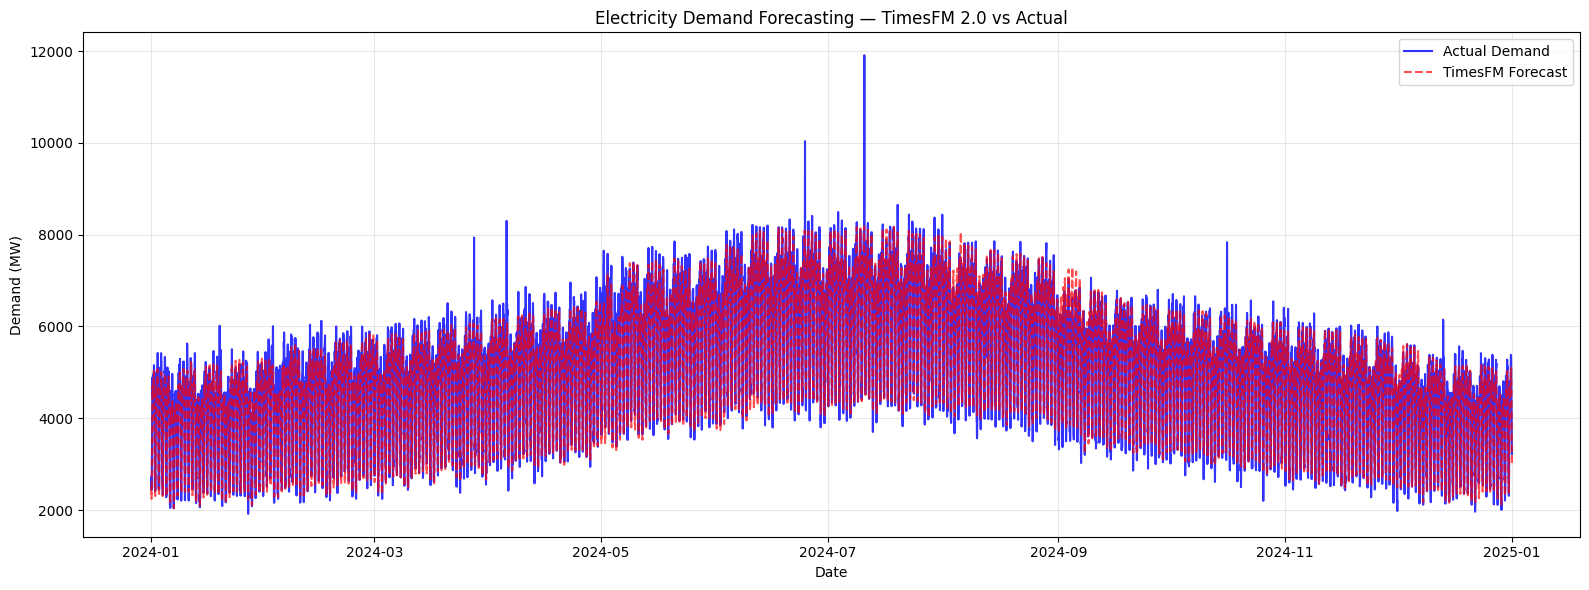

In [11]:
plt.figure(figsize=(16, 6))
plt.plot(test.index, y_true, label="Actual Demand", color="blue", alpha=0.8)
plt.plot(test.index, y_pred, label="TimesFM Forecast", color="red", linestyle="--", alpha=0.7)
plt.title("Electricity Demand Forecasting — TimesFM 2.0 vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

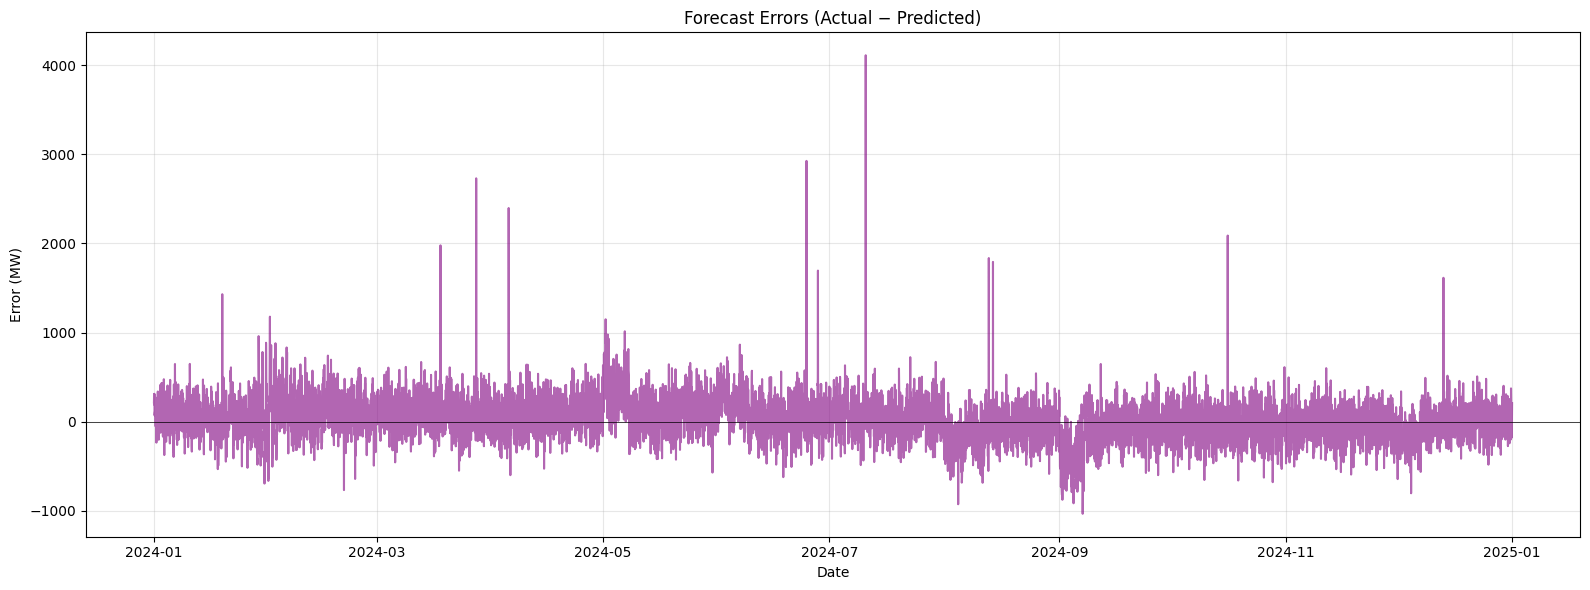

In [12]:
plt.figure(figsize=(16, 6))
errors = y_true - y_pred
plt.plot(test.index, errors, color="purple", alpha=0.6)
plt.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
plt.title("Forecast Errors (Actual − Predicted)")
plt.xlabel("Date")
plt.ylabel("Error (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Tabular Report

In [ ]:
# ====== TIMESFM MODEL PERFORMANCE REPORT ======

# --- 1. Performance Summary ---
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "MAPE (%)", "Test Samples"],
    "TimesFM 2.0": [f"{rmse_tfm:.2f}", f"{mae_tfm:.2f}", f"{mape_tfm:.2f}", f"{n_test}"],
    "XGBoost":     [f"{xgb_rmse:.2f}", f"{xgb_mae:.2f}", "2.57%", f"{n_test}"],
})
print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()

# --- 2. Actual vs Predicted Sample ---
sample_n = min(20, n_test)
compare_df = pd.DataFrame({
    "Timestamp": test.index[:sample_n],
    "Actual": y_true[:sample_n],
    "TimesFM_Pred": y_pred[:sample_n],
    "Error": y_true[:sample_n] - y_pred[:sample_n],
    "Error_%": (y_true[:sample_n] - y_pred[:sample_n]) / y_true[:sample_n] * 100,
})
for c in ["Actual", "TimesFM_Pred", "Error"]:
    compare_df[c] = compare_df[c].apply(lambda x: f"{x:.2f}")
compare_df["Error_%"] = compare_df["Error_%"].apply(lambda x: f"{x:.2f}%")
print("=" * 110)
print("ACTUAL vs PREDICTED (First 20 Test Samples)")
print("=" * 110)
print(compare_df.to_string(index=False))
print()

# --- 3. Summary Statistics ---
over_pred = np.sum(y_pred > y_true)
under_pred = np.sum(y_pred < y_true)
summary_df = pd.DataFrame({
    "Statistic": [
        "Mean Actual", "Mean Predicted",
        "Std Actual", "Std Predicted",
        "Min Actual", "Max Actual",
        "Min Predicted", "Max Predicted",
        "Over-Predictions", "Under-Predictions",
    ],
    "Value": [
        f"{y_true.mean():.2f}", f"{y_pred.mean():.2f}",
        f"{y_true.std():.2f}", f"{y_pred.std():.2f}",
        f"{y_true.min():.2f}", f"{y_true.max():.2f}",
        f"{y_pred.min():.2f}", f"{y_pred.max():.2f}",
        over_pred, under_pred,
    ]
})
print("=" * 50)
print("PREDICTION SUMMARY STATISTICS")
print("=" * 50)
print(summary_df.to_string(index=False))
print()

# --- 4. Persist to model_reports.db ---
con = duckdb.connect(r"C:\Users\tusha\Desktop\ML\project_elec_demand\model_reports.db")
con.execute("INSERT INTO model_results (model_name, rmse, mae) VALUES (?, ?, ?)",
            ["TimesFM_2.0", float(f"{rmse_tfm:.2f}"), float(f"{mae_tfm:.2f}")])
preds_to_insert = [(ts, float(a), float(p), float(a-p), float(abs(a-p)/a*100))
                   for ts, a, p in zip(test.index[:100], y_true[:100], y_pred[:100])]
con.executemany("INSERT INTO predictions (timestamp, actual, predicted, error, mape) VALUES (?, ?, ?, ?, ?)",
                preds_to_insert)
con.close()
print(f"Inserted metrics + 100 predictions into model_reports.db")
print()
print("=" * 50)
print("END OF TIMESFM REPORT")
print("=" * 50)

MODEL PERFORMANCE COMPARISON
      Metric TimesFM 2.0 XGBoost
        RMSE      247.55  173.65
         MAE      183.77  122.85
    MAPE (%)        3.83   2.57%
Test Samples        8783    8783

ACTUAL vs PREDICTED (First 20 Test Samples)
          Timestamp  Actual TimesFM_Pred   Error Error_%
2024-01-01 00:00:00 2720.61      2504.26  216.35   7.95%
2024-01-01 01:00:00 2669.65      2361.01  308.64  11.56%
2024-01-01 02:00:00 2435.58      2245.10  190.48   7.82%
2024-01-01 03:00:00 2641.04      2328.15  312.89  11.85%
2024-01-01 04:00:00 2687.95      2616.93   71.02   2.64%
2024-01-01 05:00:00 3309.36      3218.32   91.04   2.75%
2024-01-01 06:00:00 4084.10      3974.57  109.53   2.68%
2024-01-01 07:00:00 4599.97      4488.30  111.66   2.43%
2024-01-01 08:00:00 4889.10      4692.22  196.88   4.03%
2024-01-01 09:00:00 4769.66      4702.52   67.14   1.41%
2024-01-01 10:00:00 4782.43      4589.52  192.91   4.03%
2024-01-01 11:00:00 4457.94      4510.96  -53.02  -1.19%
2024-01-01 12:00:00 

: 

---